In [ ]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 訓練程式


讀取資料

從 ALL.csv 載入光譜資料（每筆是 1232 維波段 + 標籤）。

標籤包含四類：BG、PET、PP、PS

convid1+b+3_train



In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# ==== Paths & Config (請依你實際情況修改) ====
CSV_PATH  = "/content/drive/MyDrive/BL0909/M/ALL.csv"     # 末欄為 BG/PET/PP/PS
OUT_DIR   = "/content/drive/MyDrive/BL0909/M/MODEL"
IMAGE_DIR = "/content/drive/MyDrive/BL99"

os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
# === 讀取資料 ===
df = pd.read_csv(CSV_PATH)

feat_cols = df.columns[:-1]   # 除最後一欄 Label
label_col = df.columns[-1]

X = df[feat_cols].to_numpy(dtype=np.float32)  # shape: (N, 1232)
y = df[label_col].astype(str).str.upper().str.strip()

# === B+3 特徵 ===
mean_band = X.mean(axis=1, keepdims=True)
max_band  = X.max(axis=1, keepdims=True)
std_band  = X.std(axis=1, keepdims=True)

X_b3 = np.hstack([X, mean_band, max_band, std_band])   # (N, 1235)
print("X with B+3 shape:", X_b3.shape)


X with B+3 shape: (71808, 1235)


資料前處理

映射標籤成數字（0~3）並轉 one-hot。

打亂並分割為訓練集/驗證集（8:2）


In [ ]:
label_map = {"BG": 0, "PET": 1, "PP": 2, "PS": 3}
y = y.map(label_map).to_numpy()
y = to_categorical(y, num_classes=4)


In [ ]:
X_b3, y = shuffle(X_b3, y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_b3, y, test_size=0.2, random_state=42
)




建立 MLP 模型

結構：

Dense(256, relu) + BatchNorm + Dropout(0.3)

Dense(128, relu) + BatchNorm + Dropout(0.3)

Dense(4, softmax) → 輸出四類






In [ ]:
input_shape = (X_train.shape[1],)   # (1235,)
inputs = Input(shape=input_shape)

x = Dense(256, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1235)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       316,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351,364 (1.34 MB)

 Trainable params: 350,596 (1.34 MB)

 Non-trainable params: 768 (3.00 KB)

損失函數：categorical_crossentropy

優化器：Adam(learning_rate=0.0005)
訓練與早停

最多 100 epochs，batch=128。

若驗證 loss 10 次沒改善就早停

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9555 - loss: 0.1265 - val_accuracy: 0.6398 - val_loss: 2.0981
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9766 - loss: 0.0720 - val_accuracy: 0.7662 - val_loss: 0.9925
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9803 - loss: 0.0609 - val_accuracy: 0.7523 - val_loss: 1.0759
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9826 - loss: 0.0551 - val_accuracy: 0.9858 - val_loss: 0.0462
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9826 - loss: 0.0540 - val_accuracy: 0.9284 - val_loss: 0.2151
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9625 - val_loss: 0.1078
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9850 - loss: 0.0475 - val_accuracy: 0.9779 - val_loss: 0.0648
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9829 - loss: 0.0517 - val_ac

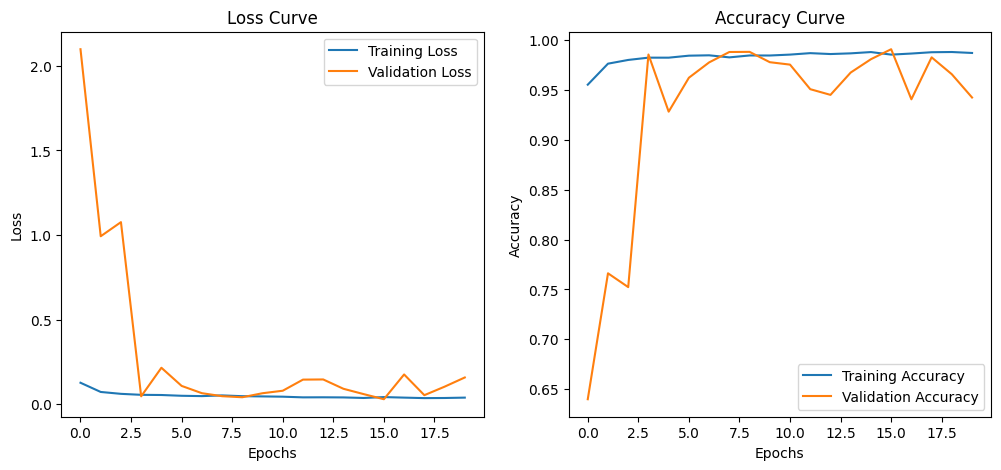

In [ ]:
import matplotlib.pyplot as plt

# Loss 曲線
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy 曲線
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


儲存模型

會輸出 20250909_MLP_B+3.keras 到指定資料夾


。

In [ ]:
MODEL_PATH = os.path.join(OUT_DIR, "0406_MLP_B+3.keras")
model.save(MODEL_PATH)
print("✅ 模型已儲存:", MODEL_PATH)


✅ 模型已儲存: /content/drive/MyDrive/BL0909/M/MODEL/0406_MLP_B+3.keras


Validation Accuracy: 0.99108759
              precision    recall  f1-score   support

          BL     0.9831    0.9839    0.9835      3732
         PET     0.9830    0.9841    0.9835      3576
          PP     0.9989    0.9972    0.9980      3550
          PS     1.0000    0.9997    0.9999      3504

    accuracy                         0.9911     14362
   macro avg     0.9912    0.9912    0.9912     14362
weighted avg     0.9911    0.9911    0.9911     14362



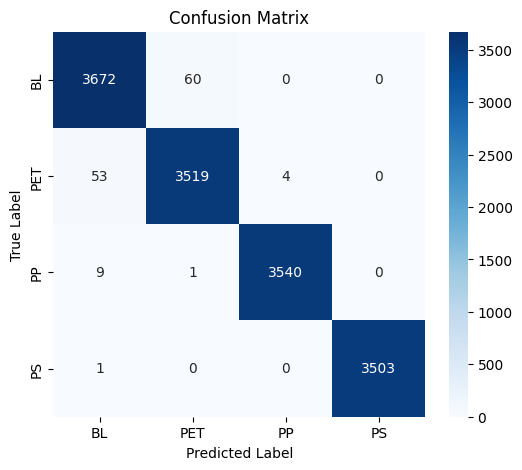

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["BL", "PET", "PP", "PS"]

# ===== 預測 =====
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# y_val 如果是 one-hot
if len(y_val.shape) > 1:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val

# ===== Accuracy =====
acc = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {acc:.8f}")

# ===== Classification Report =====
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

# ===== Confusion Matrix =====
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()